# 21 — Compare the three correlation scenarios

Run complete SBM under low, medium and high correlations and select the largest result.

Changing correlation can raise or lower capital depending on hedges. Sensitivities and risk weights stay unchanged; only correlations are transformed.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from IPython.display import display
from frtb_engine.notebook_tools import (
    INR_CRORE, bar_crore, bar_inr, configure_notebooks, crore_table,
    draw_capital_map, draw_flow, heatmap, percent_columns, display_sample,
)

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
print(f'Calculation run used in this notebook: {RUN_ID}')

Calculation run used in this notebook: SA_20260908T033903126517Z


This is the part of the calculation chain being handled here:

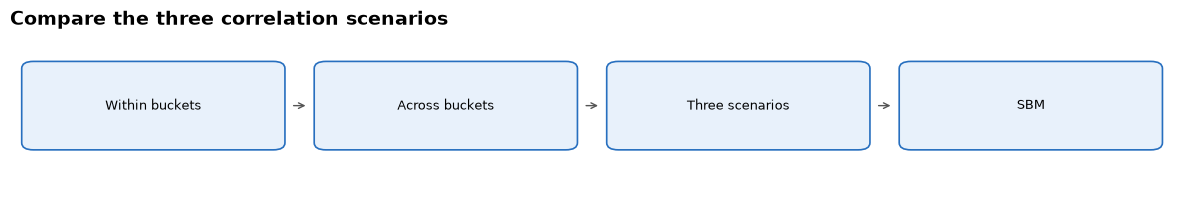

In [2]:
draw_flow(['Within buckets', 'Across buckets', 'Three scenarios', 'SBM'],'Compare the three correlation scenarios',wrap_after=4)

Recalculate all seven classes and all three measures under each scenario, then select the largest total.

$$SBM=\max(SBM_{low},SBM_{medium},SBM_{high})$$

In [3]:
scenarios=pd.read_csv(RUN/'10_sbm_scenarios.csv')
scenarios['SBM capital (INR crore)']=scenarios.sbm_capital/INR_CRORE
scenarios['selected']=scenarios.sbm_capital==scenarios.sbm_capital.max()
display(scenarios[['scenario','SBM capital (INR crore)','selected']])
selected=scenarios.loc[scenarios.sbm_capital.idxmax()]
print(f"Selected scenario: {selected.scenario} | INR {selected.sbm_capital/INR_CRORE:,.4f} crore")

,scenario,SBM capital (INR crore),selected
0,low,87.2086,False
1,medium,89.4464,False
2,high,91.4954,True


Selected scenario: high | INR 91.4954 crore


The visual below uses the calculated rows shown above.

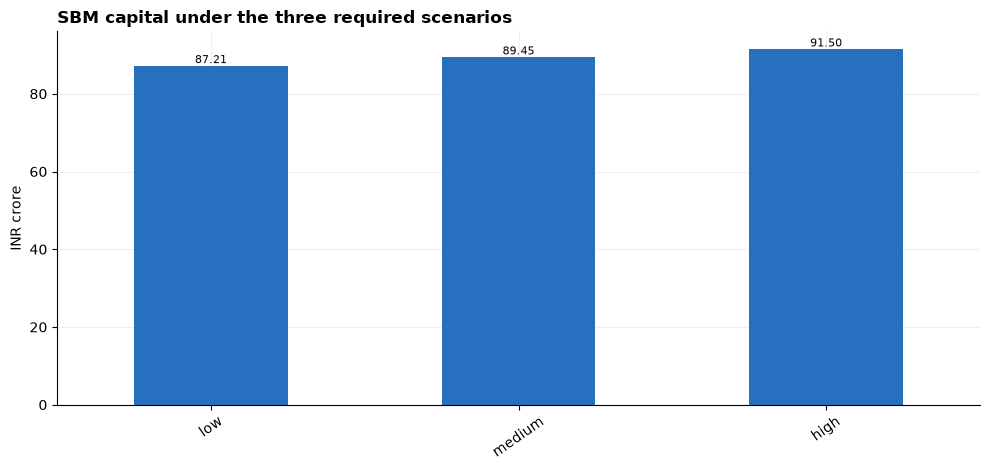

In [4]:
bar_crore(scenarios.set_index('scenario')['sbm_capital'],'SBM capital under the three required scenarios')

Only the largest scenario total enters final FRTB SA capital.